In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

### Function Description

Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 

To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

In [33]:
# Load data
X = np.load('initial_inputs.npy')
Y = np.load('initial_outputs.npy')

In [34]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['target'] = Y

print(df.head(10))
print()
print(df.describe())


         x1        x2    target
0  0.665800  0.123969  0.538996
1  0.877791  0.778628  0.420586
2  0.142699  0.349005 -0.065624
3  0.845275  0.711120  0.293993
4  0.454647  0.290455  0.214965
5  0.577713  0.771973  0.023106
6  0.438166  0.685018  0.244619
7  0.341750  0.028698  0.038749
8  0.338648  0.213867 -0.013858
9  0.702637  0.926564  0.611205

              x1         x2     target
count  10.000000  10.000000  10.000000
mean    0.538513   0.487930   0.230674
std     0.237188   0.320245   0.237555
min     0.142699   0.028698  -0.065624
25%     0.365854   0.233014   0.027016
50%     0.516180   0.517012   0.229792
75%     0.693427   0.756760   0.388938
max     0.877791   0.926564   0.611205


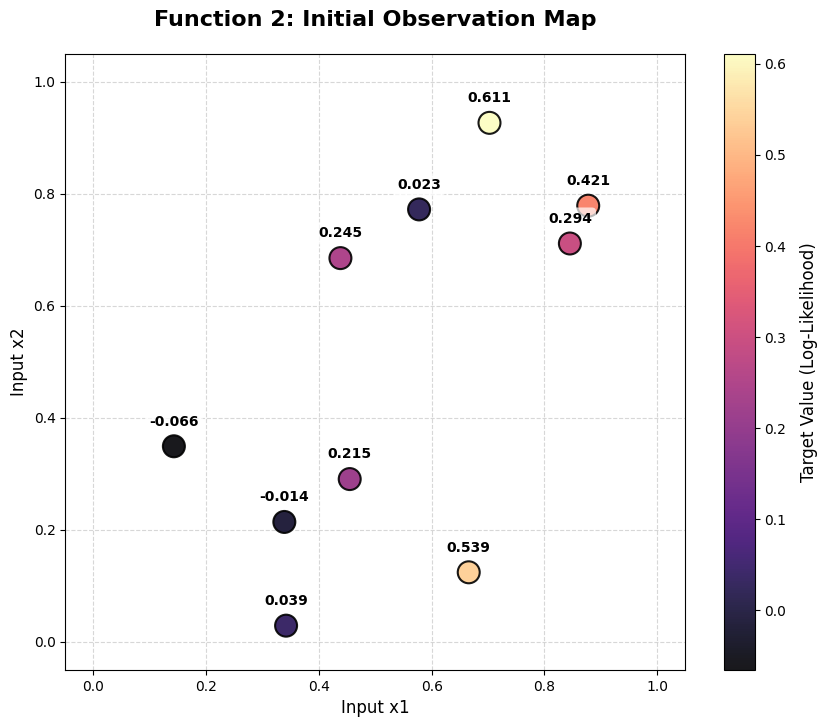

In [35]:
# Create the visualization
plt.figure(figsize=(10, 8))

# Plot the points with a color gradient based on the target value
scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='magma', s=250, edgecolor='black', linewidth=1.5, alpha=0.9, zorder=3)

# Add a colorbar to act as a legend for the values
cbar = plt.colorbar(scatter)
cbar.set_label('Target Value (Log-Likelihood)', fontsize=12, labelpad=10)

# 3. Label each point with its value for easy reference
for i, val in enumerate(Y):
    plt.annotate(f"{val:.3f}", (X[i, 0], X[i, 1]), 
                 textcoords="offset points", 
                 xytext=(0, 15), 
                 ha='center', 
                 fontsize=10, 
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='none'))

# 4. Final Styling
plt.title("Function 2: Initial Observation Map", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Input x1", fontsize=12)
plt.ylabel("Input x2", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

plt.show()

In [37]:
kernel = RationalQuadratic(length_scale=0.2, length_scale_bounds=(0.05, 0.5), alpha=0.1) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-3, 0.1))

# 2. Initialize the Surrogate with Normalization
# Using n_restarts_optimizer=20 helps us avoid getting stuck in a local kernel fit
model = GaussianProcessRegressor(
    kernel=kernel, 
    normalize_y=True, 
    n_restarts_optimizer=20,
    random_state=42
)

# 3. Fit the model to your Function 2 data
model.fit(X, Y)

# 4. Create a dense search grid
res = 100
x_vals = np.linspace(0, 1, res)
y_vals = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# 5. Tweak your Strategy (Beta)
# 1.96 is balanced; 3.0+ is aggressive exploration; 0.1 is pure exploitation
beta = 2.0 

# 6. Predict and calculate UCB
# UCB = \mu(x) + \beta \sigma(x)
mean, std = model.predict(grid_points, return_std=True)
ucb_scores = mean + beta * std

# 7. Find the winning coordinate
best_idx = np.argmax(ucb_scores)
next_query = grid_points[best_idx]

print()
print(f"FUNCTION 2 SUGGESTION (Beta={beta})")
print()
print(f"Next Query x1: {next_query[0]:.6f}")
print(f"Next Query x2: {next_query[1]:.6f}")

NameError: name 'RationalQuadratic' is not defined

In [6]:
res = 150
x_vals = np.linspace(0, 1, res)
y_vals = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# 5. Predict Mean and Uncertainty
mean, std = model.predict(grid_points, return_std=True)

# 6. Sweep through your requested Beta values
betas = [0.1, 0.5, 1, 1.5, 2, 2.5]
suggested_points = []

print("--- Beta Sweep Coordinates ---")
for b in betas:
    ucb = mean + b * std
    best_idx = np.argmax(ucb)
    point = grid_points[best_idx]
    suggested_points.append(point)
    print(f"Beta {b}: (x1={point[0]:.4f}, x2={point[1]:.4f})")

suggested_points = np.array(suggested_points)

# 7. Visualization
plt.figure(figsize=(10, 8))

# Background: Uncertainty (The Blue "Fog")
plt.contourf(X_grid, Y_grid, std.reshape(res, res), cmap='Blues', alpha=0.3)
plt.colorbar(label='Uncertainty (Standard Deviation)')

# Plot original 10 data points
plt.scatter(X[:, 0], X[:, 1], c='black', marker='x', s=100, label='Initial Data', zorder=5)

# Plot the Beta Trail (from dark to light)
colors = plt.cm.YlOrRd(np.linspace(0.3, 1, len(betas)))
for i, b in enumerate(betas):
    plt.scatter(suggested_points[i, 0], suggested_points[i, 1], 
                color=colors[i], edgecolor='black', s=200, 
                label=f'Beta={b}', zorder=10)

# Connect with a dashed line to see the "climb"
plt.plot(suggested_points[:, 0], suggested_points[:, 1], 'r--', alpha=0.4, zorder=8)

plt.title("Function 2: The Beta Sweep Trail", fontsize=14)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

### Week 1 submission: x1 = 0.8121, x2 = 0.9664

* Current State: You have a clear signal (0.611), but you’ve been warned about multiple local peaks and sensor noise. We are no longer searching in total darkness; we are "climbing" a specific ridge.

* The Model Choice: Rational Quadratic (RQ) + White Kernel.
    * RQ Reasoning: Unlike standard kernels, RQ can model broad "high-ground" areas while still allowing for the sharp, local spikes mentioned in the description.
    * White Kernel Reasoning: It explicitly models the "noise" so the optimizer doesn't get tricked by a single lucky (or unlucky) high reading.

* The "Edge Magnet" Fix: We enabled normalize_y=True.
    * This prevents the model from "flatlining" and assuming the unexplored corners are zero. Instead, it assumes the unknown is "average," which makes your 0.611 peak stand out as a genuine destination.

* The "Beta Sweep" Result: As curiosity (β) increases, the suggested points don't jump to the empty corners. Instead, they "march" further into the top-right.

* The 10-Query Phased Plan:
    1. Phase 1 (Verify): Use the next 2 queries to see if the top-right peak keeps rising or if it’s a "false summit."
    2. Phase 2 (Scout): If the peak flattens, pivot to a high β (3.0+) to check the "Big Empty" (the bottom-left quadrant) to ensure the global maximum isn't hiding there.
    3. Phase 3 (Snipe): Once the true "Global Hill" is identified, drop β to 0.1 to pinpoint the absolute highest coordinate.


In [7]:
# ---------------------------------------------------
# WEEK1: NEW DATA HERE
# ---------------------------------------------------
w1_new_input = [0.8121, 0.9664]
w1_new_output = -0.04807549736452112
# ---------------------------------------------------

# Format the new data strictly to prevent sklearn crashes
new_X = np.atleast_2d(w1_new_input)
new_Y = np.atleast_1d(w1_new_output)

# Merge the arrays
X_updated_w1 = np.vstack((X, new_X))
Y_updated_w1 = np.append(Y, new_Y)

df = pd.DataFrame(X_updated_w1, columns=['x1', 'x2'])
df['target'] = Y_updated_w1

print(df.describe())
print(df.head(11))

              x1         x2     target
count  11.000000  11.000000  11.000000
mean    0.563384   0.531427   0.205333
std     0.239660   0.336323   0.240526
min     0.142699   0.028698  -0.065624
25%     0.389958   0.252161   0.004624
50%     0.577713   0.685018   0.214965
75%     0.757368   0.775300   0.357290
max     0.877791   0.966400   0.611205
          x1        x2    target
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.812100  0.966400 -0.048075


In [31]:
kernel = RationalQuadratic(length_scale=0.2, length_scale_bounds=(0.05, 0.5), alpha=0.1) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-3, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    normalize_y=True, 
    n_restarts_optimizer=20,
    random_state=42
)

model.fit(X_updated_w1, Y_updated_w1)

mean, std = model.predict(grid_points, return_std=True)

betas = [0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3.0, 3.5, 4.0]
suggested_points = []
sweep_results = [] 

print("--- Beta Sweep Coordinates ---")
for b in betas:
    ucb = mean + b * std
    best_idx = np.argmax(ucb)
    point = grid_points[best_idx]
    bp = grid_points[best_idx]
    suggested_points.append(point)
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': mean[best_idx],
        'Uncert': std[best_idx]
    })

suggested_points = np.round(np.array(suggested_points), 8)

df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

NameError: name 'RationalQuadratic' is not defined

### Week 2 submission:

Round 1: The Cliff Dive:

* Action: Attempted to explore the space just behind our best initial point ([0.7026, 0.9265], score: 0.611) using a high β=2.5 at coordinate [0.8121, 0.9664].
* Result: The score plummeted to -0.048.
* The Insight: We didn't find a broad plateau. This triggered a massive mathematical correction. The model's length scale crashed to the absolute minimum (0.05), making it extremely "nearsighted" and cautious of steep drops everywhere.

Round 2: The Micro-Step (Current):
* The Strategy: Pure Exploitation (β=0.25). We are executing a strict "Snipe" maneuver.
* The Chosen Query: [0.69127517, 0.92617450]
* The Logic: We are testing if we can quickly and cheaply capture the true summit of this local optimum. If this low-beta move doesn't yield a higher score, the mathematical "cost" of climbing this specific jagged mountain is too high, and we will pivot to exploring other quadrants.

In [9]:
# ---------------------------------------------------
# WEEK2: NEW DATA HERE
# ---------------------------------------------------

w2_new_input = [0.691275, 0.926174]
w2_new_output = np.float64(0.6316393708691275)

w2_new_X = np.atleast_2d(w2_new_input)
w2_new_Y = np.atleast_1d(w2_new_output)

X_updated_w2 = np.vstack((X_updated_w1, w2_new_X))
Y_updated_w2 = np.append(Y_updated_w1, w2_new_Y)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_updated_w2_scaled = scaler_x.fit_transform(X_updated_w2)
Y_updated_w2_scaled = scaler_y.fit_transform(Y_updated_w2.reshape(-1, 1))

df = pd.DataFrame(X_updated_w2, columns=['x1', 'x2'])
df['target'] = Y_updated_w2

print(df.describe())
print(df.head(12))

              x1         x2     target
count  12.000000  12.000000  12.000000
mean    0.574042   0.564323   0.240858
std     0.231470   0.340317   0.260266
min     0.142699   0.028698  -0.065624
25%     0.414062   0.271308   0.013865
50%     0.621756   0.698069   0.229792
75%     0.730002   0.815514   0.450189
max     0.877791   0.966400   0.631639
          x1        x2    target
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.812100  0.966400 -0.048075
11  0.691275  0.926174  0.631639


In [10]:
kernel = C(1.0, (1e-3, 1000)) * RBF(length_scale=0.2, length_scale_bounds=(0.05, 0.5)) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=20,
    random_state=42
)

model.fit(X_updated_w2_scaled, Y_updated_w2_scaled)

res = 150 
x_coord = np.linspace(0, 1, res)
y_coord = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_coord, y_coord)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

grid_points_scaled = scaler_x.transform(grid_points)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3.0]
sweep_results = [] 

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    # Safely inverse transform the single best value
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    
    bp = grid_points[best_idx]
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- NEXT QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.100000 0.684564 0.932886   0.632201 0.019649
0.250000 0.684564 0.939597   0.628381 0.037280
0.500000 0.684564 0.946309   0.622032 0.054848
1.000000 0.684564 0.973154   0.574712 0.119202
1.500000 0.684564 0.986577   0.541183 0.146040
2.000000 0.677852 1.000000   0.503409 0.169143
2.500000 0.677852 1.000000   0.503409 0.169143
3.000000 0.697987 0.832215   0.438627 0.193506

--- Optimized Kernel Parameters ---
0.925**2 * RBF(length_scale=0.26) + WhiteKernel(noise_level=1e-05)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 3 submission:

* Model Architecture Shift: Replaced the Rational Quadratic kernel with a robust RBF + WhiteKernel configuration to better capture the localized, single-peak contamination signal.

* Data Normalization: Integrated StandardScaler for both X coordinates and Y targets. This resolved the numerical instability and "ABNORMAL" warnings encountered in previous runs.

* Strategy Pivot: Transitioned from space-filling exploration to  This prioritizes the predicted peak over unexplored regions.

* Coordinate Selection: [0.684564,0.932886] for the next query. moving into high-precision exploitation by setting the acquisition parameter β to 0.1 (from the previous β=2.5). 



In [11]:
# ---------------------------------------------------
# WEEK3: NEW DATA HERE
# ---------------------------------------------------

w3_new_input = [0.684564, 0.932886]
w3_new_output = 0.6564382131558532

w3_new_X = np.atleast_2d(w3_new_input)
w3_new_Y = np.atleast_1d(w3_new_output)

X_updated_w3 = np.vstack((X_updated_w2, w3_new_X))
Y_updated_w3 = np.append(Y_updated_w2, w3_new_Y)

X_updated_w3_scaled = scaler_x.fit_transform(X_updated_w3)
Y_updated_w3_scaled = scaler_y.fit_transform(Y_updated_w3.reshape(-1, 1))

df = pd.DataFrame(X_updated_w3, columns=['x1', 'x2'])
df['target'] = Y_updated_w3

print(df.head(13))
print(df.describe())

          x1        x2    target
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.812100  0.966400 -0.048075
11  0.691275  0.926174  0.631639
12  0.684564  0.932886  0.656438
              x1         x2     target
count  13.000000  13.000000  13.000000
mean    0.582543   0.592674   0.272826
std     0.223725   0.341487   0.274552
min     0.142699   0.028698  -0.065624
25%     0.438166   0.290455   0.023106
50%     0.665800   0.711120   0.244619
75%     0.702637   0.926174   0.538996
max     0.877791   0.966400   0.656438


In [12]:
model.fit(X_updated_w3_scaled, Y_updated_w3_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3.0]
sweep_results = [] 

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    # Safely inverse transform the single best value
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    
    bp = grid_points[best_idx]
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- NEXT QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.100000 0.671141 0.946309   0.696868 0.066800
0.250000 0.671141 0.946309   0.696868 0.066800
0.500000 0.671141 0.953020   0.693196 0.078194
1.000000 0.671141 0.973154   0.667754 0.113058
1.500000 0.671141 0.993289   0.624707 0.146620
2.000000 0.671141 1.000000   0.607553 0.157028
2.500000 0.671141 1.000000   0.607553 0.157028
3.000000 0.610738 1.000000   0.478044 0.202278

--- Optimized Kernel Parameters ---
0.921**2 * RBF(length_scale=0.291) + WhiteKernel(noise_level=0.000411)


### Week 4 submission:

Next point to query [0.671141 , 0.946309] Beta = 0.1 - 0.25

* Switching to optimization has paid off, we have found a new max point. 
* Sticking with the same strategy, the beta sweep shows a concentration on one point for x1 (beta = 0.1 - 2.5) and the also some convergence on x2 (beta = 0.1 - 0.25)

In [13]:
# ---------------------------------------------------
# WEEK4: NEW DATA HERE
# ---------------------------------------------------

w4_new_input = 	[0.671141, 0.946309]
w4_new_output = 0.5772478242135415

w4_new_X = np.atleast_2d(w4_new_input)
w4_new_Y = np.atleast_1d(w4_new_output)

X_updated_w4 = np.vstack((X_updated_w3, w4_new_X))
Y_updated_w4 = np.append(Y_updated_w3, w4_new_Y)

X_updated_w4_scaled = scaler_x.fit_transform(X_updated_w4)
Y_updated_w4_scaled = scaler_y.fit_transform(Y_updated_w4.reshape(-1, 1))

df = pd.DataFrame(X_updated_w4, columns=['x1', 'x2'])
df['target'] = Y_updated_w4

print(df.describe())

              x1         x2     target
count  14.000000  14.000000  14.000000
mean    0.588872   0.617933   0.294571
std     0.216248   0.341432   0.276043
min     0.142699   0.028698  -0.065624
25%     0.442286   0.305093   0.027016
50%     0.668470   0.741547   0.269306
75%     0.699796   0.926467   0.567685
max     0.877791   0.966400   0.656438


In [38]:
model.fit(X_updated_w4_scaled, Y_updated_w4_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3.0]
sweep_results = [] 

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    # Safely inverse transform the single best value
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    
    bp = grid_points[best_idx]
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- NEXT QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.100000 0.677852 1.000000   0.660960 0.020868
0.250000 0.677852 1.000000   0.660960 0.020868
0.500000 0.677852 0.000000   0.660960 0.020868
1.000000 0.677852 0.000000   0.660960 0.020868
1.500000 0.979866 0.000000   0.357987 0.238640
2.000000 0.986577 0.000000   0.354977 0.240390
2.500000 1.000000 0.000000   0.350310 0.242545
3.000000 1.000000 0.000000   0.350310 0.242545

--- Optimized Kernel Parameters ---
Matern(length_scale=[0.249, 1e+05], nu=2.5) + WhiteKernel(noise_level=0.00486)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 5 submission:

Next point to query: [0.684564 0.758389] beta = 3.0 

* Further optimization hasn't paid off 
* Switching to exploration - want to validate the models prediction, as it predicts a higher mean for higher exploration 
* Worth investigating this phenomenon 

In [15]:
# ---------------------------------------------------
# WEEK5: NEW DATA HERE
# ---------------------------------------------------

w5_new_input = 	[0.684564, 0.758389]
w5_new_output = 0.5226690523149875

w5_new_X = np.atleast_2d(w5_new_input)
w5_new_Y = np.atleast_1d(w5_new_output)

X_updated_w5 = np.vstack((X_updated_w4, w5_new_X))
Y_updated_w5 = np.append(Y_updated_w4, w5_new_Y)

X_updated_w5_scaled = scaler_x.fit_transform(X_updated_w5)
Y_updated_w5_scaled = scaler_y.fit_transform(Y_updated_w5.reshape(-1, 1))

df = pd.DataFrame(X_updated_w5, columns=['x1', 'x2'])
df['target'] = Y_updated_w5

print(df.describe())

              x1         x2     target
count  15.000000  15.000000  15.000000
mean    0.595251   0.627297   0.309777
std     0.209842   0.331005   0.272443
min     0.142699   0.028698  -0.065624
25%     0.446407   0.319730   0.030927
50%     0.671141   0.758389   0.293993
75%     0.696956   0.926369   0.558122
max     0.877791   0.966400   0.656438


In [16]:
model.fit(X_updated_w5_scaled, Y_updated_w5_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.25, 0.5, 1, 1.5, 2, 2.5, 3.0]
sweep_results = [] 

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    # Safely inverse transform the single best value
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    
    bp = grid_points[best_idx]
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- NEXT QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.250000 0.671141 0.818792   0.663819 0.100385
0.500000 0.671141 0.812081   0.660578 0.107229
1.000000 0.671141 0.805369   0.656149 0.112859
1.500000 0.671141 0.798658   0.650662 0.117161
2.000000 0.671141 0.798658   0.650662 0.117161
2.500000 0.738255 0.006711   0.389763 0.230562
3.000000 0.738255 0.120805   0.377996 0.234878

--- Optimized Kernel Parameters ---
0.931**2 * RBF(length_scale=0.288) + WhiteKernel(noise_level=0.00724)


### Week 6 submission:

Next point to query: [0.738255 0.006711] beta = 2.5

* Doing another round of exploration 
* Avoid optimising into the same area as before / check some distance matrices before going into exploration

In [17]:
# ---------------------------------------------------
# WEEK6: NEW DATA HERE
# ---------------------------------------------------

w6_new_input = 	[0.738255, 0.006711]
w6_new_output = 0.4243068488843498

w6_new_X = np.atleast_2d(w6_new_input)
w6_new_Y = np.atleast_1d(w6_new_output)

X_updated_w6 = np.vstack((X_updated_w5, w6_new_X))
Y_updated_w6 = np.append(Y_updated_w5, w6_new_Y)

X_updated_w6_scaled = scaler_x.fit_transform(X_updated_w6)
Y_updated_w6_scaled = scaler_y.fit_transform(Y_updated_w6.reshape(-1, 1))

df = pd.DataFrame(X_updated_w6, columns=['x1', 'x2'])
df['target'] = Y_updated_w6

print(df.head(16))

          x1        x2    target
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.812100  0.966400 -0.048075
11  0.691275  0.926174  0.631639
12  0.684564  0.932886  0.656438
13  0.671141  0.946309  0.577248
14  0.684564  0.758389  0.522669
15  0.738255  0.006711  0.424307


In [18]:
model.fit(X_updated_w6_scaled, Y_updated_w6_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.25, 0.5, 1, 1.5, 2, 2.5, 3.0]
sweep_results = [] 

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    # Safely inverse transform the single best value
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    
    bp = grid_points[best_idx]
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- NEXT QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.250000 0.664430 0.838926   0.664825 0.084110
0.500000 0.664430 0.832215   0.662772 0.090188
1.000000 0.664430 0.825503   0.659383 0.095090
1.500000 0.664430 0.818792   0.654750 0.098716
2.000000 0.664430 0.818792   0.654750 0.098716
2.500000 0.597315 0.000000   0.398085 0.224417
3.000000 0.731544 0.201342   0.386716 0.228591

--- Optimized Kernel Parameters ---
0.932**2 * RBF(length_scale=0.299) + WhiteKernel(noise_level=0.00774)


### Week 7 submission

Next point to query [0.664430 0.832215] beta = 0.5

* Change next round into data masking and training with a subset of high performing data. 

In [19]:
# ---------------------------------------------------
# WEEK7: NEW DATA HERE
# ---------------------------------------------------

w7_new_input = 	[0.664430, 0.832215]
w7_new_output = 0.561116984289508

w7_new_X = np.atleast_2d(w7_new_input)
w7_new_Y = np.atleast_1d(w7_new_output)

X_updated_w7 = np.vstack((X_updated_w6, w7_new_X))
Y_updated_w7 = np.append(Y_updated_w6, w7_new_Y)

X_updated_w7_scaled = scaler_x.fit_transform(X_updated_w7)
Y_updated_w7_scaled = scaler_y.fit_transform(Y_updated_w7.reshape(-1, 1))

df = pd.DataFrame(X_updated_w7, columns=['x1', 'x2'])
df['target'] = Y_updated_w7

print(df.describe())
# print(df.head(17))

              x1         x2     target
count  17.000000  17.000000  17.000000
mean    0.607733   0.602846   0.331299
std     0.199853   0.349183   0.263103
min     0.142699   0.006711  -0.065624
25%     0.454647   0.290455   0.038749
50%     0.671141   0.758389   0.420586
75%     0.702637   0.926174   0.561117
max     0.877791   0.966400   0.656438


In [20]:
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.01, 100000.0), nu=2.5) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=50,  
    random_state=42
)

model.fit(X_updated_w7_scaled, Y_updated_w7_scaled)

mean_grid, std_grid = model.predict(grid_points_scaled, return_std=True)
mean_grid = mean_grid.flatten()
std_grid = std_grid.flatten()

def negative_ucb(x_active, gp_model, beta):
    mean, std = gp_model.predict(x_active.reshape(1, -1), return_std=True)
    ucb = mean[0] + (beta * std[0])
    return -ucb 

betas = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
sweep_results = [] 

raw_lower = [[0, 0]]
raw_upper = [[1, 1]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]
bounds = [(scaled_lower[0], scaled_upper[0]), (scaled_lower[1], scaled_upper[1])]

for b in betas:
    ucb_grid = mean_grid + (b * std_grid)
    best_grid_idx = np.argmax(ucb_grid)
    x0_guess = grid_points_scaled[best_grid_idx]

    res = minimize(
        fun=negative_ucb,
        x0=x0_guess,
        args=(model, b),
        method='L-BFGS-B',
        bounds=bounds
    )
    best_x_scaled = res.x
    best_x_raw = scaler_x.inverse_transform([best_x_scaled])[0]
    mean_opt, std_opt = model.predict([best_x_scaled], return_std=True)
    actual_mean = scaler_y.inverse_transform([[mean_opt[0]]])[0][0]
    actual_std = std_opt[0] * scaler_y.scale_[0]
    
    sweep_results.append({
        'Beta': b,
        'x1': best_x_raw[0],
        'x2': best_x_raw[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

print("\n--- CONTINUOUS L-BFGS-B QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- CONTINUOUS L-BFGS-B QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.250000 0.664430 0.838926   0.664825 0.084110
0.500000 0.664430 0.832215   0.662772 0.090188
1.000000 0.664430 0.825503   0.659383 0.095090
1.500000 0.664430 0.818792   0.654750 0.098716
2.000000 0.664430 0.818792   0.654750 0.098716
2.500000 0.597315 0.000000   0.398085 0.224417
3.000000 0.731544 0.201342   0.386716 0.228591

--- Optimized Kernel Parameters ---
Matern(length_scale=[0.292, 6.35e+04], nu=2.5) + WhiteKernel(noise_level=0.0309)


### Week 8 submission

Next point to query [0.671141 0.825503] beta = 0.5

* Updated the kernel for Matern
* Changed the optimisation method 

In [21]:
# ---------------------------------------------------
# WEEK8: NEW DATA HERE
# ---------------------------------------------------

w8_new_input = 	[0.671141, 0.825503]
w8_new_output = 0.48894689239821604

w8_new_X = np.atleast_2d(w8_new_input)
w8_new_Y = np.atleast_1d(w8_new_output)

X_updated_w8 = np.vstack((X_updated_w7, w8_new_X))
Y_updated_w8 = np.append(Y_updated_w7, w8_new_Y)

X_updated_w8_scaled = scaler_x.fit_transform(X_updated_w8)
Y_updated_w8_scaled = scaler_y.fit_transform(Y_updated_w8.reshape(-1, 1))

df = pd.DataFrame(X_updated_w8, columns=['x1', 'x2'])
df['target'] = Y_updated_w8

print(df.describe())

              x1         x2     target
count  18.000000  18.000000  18.000000
mean    0.611255   0.615216   0.340057
std     0.194461   0.342798   0.257938
min     0.142699   0.006711  -0.065624
25%     0.485414   0.305093   0.082803
50%     0.671141   0.765181   0.422447
75%     0.699796   0.902684   0.555587
max     0.877791   0.966400   0.656438


In [22]:
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.01, 100000.0), nu=2.5) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=50,  
    random_state=42
)

model.fit(X_updated_w8_scaled, Y_updated_w8_scaled)

mean_grid, std_grid = model.predict(grid_points_scaled, return_std=True)
mean_grid = mean_grid.flatten()
std_grid = std_grid.flatten()

def negative_ucb(x_active, gp_model, beta):
    mean, std = gp_model.predict(x_active.reshape(1, -1), return_std=True)
    ucb = mean[0] + (beta * std[0])
    return -ucb 

betas = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
sweep_results = [] 

raw_lower = [[0, 0]]
raw_upper = [[1, 1]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]
bounds = [(scaled_lower[0], scaled_upper[0]), (scaled_lower[1], scaled_upper[1])]

for b in betas:
    ucb_grid = mean_grid + (b * std_grid)
    best_grid_idx = np.argmax(ucb_grid)
    x0_guess = grid_points_scaled[best_grid_idx]

    res = minimize(
        fun=negative_ucb,
        x0=x0_guess,
        args=(model, b),
        method='L-BFGS-B',
        bounds=bounds
    )
    best_x_scaled = res.x
    best_x_raw = scaler_x.inverse_transform([best_x_scaled])[0]
    mean_opt, std_opt = model.predict([best_x_scaled], return_std=True)
    actual_mean = scaler_y.inverse_transform([[mean_opt[0]]])[0][0]
    actual_std = std_opt[0] * scaler_y.scale_[0]
    
    sweep_results.append({
        'Beta': b,
        'x1': best_x_raw[0],
        'x2': best_x_raw[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

print("\n--- CONTINUOUS L-BFGS-B QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- CONTINUOUS L-BFGS-B QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.250000 0.664430 0.838926   0.664825 0.084110
0.500000 0.664430 0.832215   0.662772 0.090188
1.000000 0.664430 0.825503   0.659383 0.095090
1.500000 0.664430 0.818792   0.654750 0.098716
2.000000 0.664430 0.818792   0.654750 0.098716
2.500000 0.597315 0.000000   0.398085 0.224417
3.000000 0.731544 0.201342   0.386716 0.228591

--- Optimized Kernel Parameters ---
Matern(length_scale=[0.294, 1e+05], nu=2.5) + WhiteKernel(noise_level=0.0394)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 9 submission

Next point to query [0.664430 0.838926] beta = 0.25

* Didn't improve, wasn't close
* Trying a smaller beta

In [23]:
# ---------------------------------------------------
# WEEK9: NEW DATA HERE
# ---------------------------------------------------

w9_new_input = [0.664430, 0.838926]
w9_new_output = 0.34630580663347205

w9_new_X = np.atleast_2d(w9_new_input)
w9_new_Y = np.atleast_1d(w9_new_output)

X_updated_w9 = np.vstack((X_updated_w8, w9_new_X))
Y_updated_w9 = np.append(Y_updated_w8, w9_new_Y)

X_updated_w9_scaled = scaler_x.fit_transform(X_updated_w9)
Y_updated_w9_scaled = scaler_y.fit_transform(Y_updated_w9.reshape(-1, 1))

df = pd.DataFrame(X_updated_w9, columns=['x1', 'x2'])
df['target'] = Y_updated_w9

print(df.describe())

              x1         x2     target
count  19.000000  19.000000  19.000000
mean    0.614054   0.626990   0.340386
std     0.189375   0.337070   0.250675
min     0.142699   0.006711  -0.065624
25%     0.516180   0.319730   0.126857
50%     0.671141   0.771973   0.420586
75%     0.696956   0.882550   0.550057
max     0.877791   0.966400   0.656438


In [30]:
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.01, 100000.0), nu=2.5) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=50,  
    random_state=42
)

model.fit(X_updated_w9_scaled, Y_updated_w9_scaled)

mean_grid, std_grid = model.predict(grid_points_scaled, return_std=True)
mean_grid = mean_grid.flatten()
std_grid = std_grid.flatten()

def negative_ucb(x_active, gp_model, beta):
    mean, std = gp_model.predict(x_active.reshape(1, -1), return_std=True)
    ucb = mean[0] + (beta * std[0])
    return -ucb 

betas = [0.05, 0.15, 0.25, 0.5, 1.0, 1.5]
sweep_results = [] 

raw_lower = [[0, 0]]
raw_upper = [[1, 1]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]
bounds = [(scaled_lower[0], scaled_upper[0]), (scaled_lower[1], scaled_upper[1])]

for b in betas:
    ucb_grid = mean_grid + (b * std_grid)
    best_grid_idx = np.argmax(ucb_grid)
    x0_guess = grid_points_scaled[best_grid_idx]

    res = minimize(
        fun=negative_ucb,
        x0=x0_guess,
        args=(model, b),
        method='L-BFGS-B',
        bounds=bounds
    )
    best_x_scaled = res.x
    best_x_raw = scaler_x.inverse_transform([best_x_scaled])[0]
    mean_opt, std_opt = model.predict([best_x_scaled], return_std=True)
    actual_mean = scaler_y.inverse_transform([[mean_opt[0]]])[0][0]
    actual_std = std_opt[0] * scaler_y.scale_[0]
    
    sweep_results.append({
        'Beta': b,
        'x1': best_x_raw[0],
        'x2': best_x_raw[1],
        'Pred Mean': actual_mean,
        'Uncert': actual_std
    })

df_sweep = pd.DataFrame(sweep_results)

print("\n--- CONTINUOUS L-BFGS-B QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- CONTINUOUS L-BFGS-B QUERY SUGGESTIONS ---
    Beta       x1       x2  Pred Mean   Uncert
0.050000 0.696695 0.619664   0.609612 0.082645
0.150000 0.696879 0.538571   0.609602 0.082738
0.250000 0.697068 0.389900   0.609583 0.082835
0.500000 0.697562 0.058769   0.609485 0.083094
1.000000 0.698656 0.058769   0.609028 0.083697
1.500000 0.959700 0.058769   0.371872 0.243996

--- Optimized Kernel Parameters ---
Matern(length_scale=[0.297, 6.35e+04], nu=2.5) + WhiteKernel(noise_level=0.0868)


### Week 10 submission

Next point to query [0.696695 0.619664] beta = 0.05

* Caught a bug in the code - saving old sweep results
* Trying a smaller beta